# AdaBoost Regressor 2 - Model Development Workflow

> **MLCourse · Machine Learning · supervised · regression**

### What you'll learn
- A repeatable workflow: split → baselines → boost → diagnose → tune
- Why regressors have NO `staged_score`: how to build a rounds-vs-R² curve yourself
- How `loss` interacts with early stopping (the silent 21-round problem)
- A learning-rate × loss mini-grid, read as a heatmap
- Reading `feature_importances_` from boosted stumps

### Standard first cell: plotting + imports + reproducibility.


In [ ]:
# Inline plotting for Jupyter; plain-Python runs fall through harmlessly.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:            # no IPython here -> nothing to wire up
    pass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor                 # predict-the-mean floor
from sklearn.linear_model import LinearRegression        # familiar reference point
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

def find_data_dir() -> Path:
    # walk up until we enter the course folder '02_machine_learning'
    here = Path.cwd()
    for candidate in [here, *here.parents]:
        if candidate.name == "02_machine_learning":
            return candidate / "data"
    raise FileNotFoundError("Could not locate the 02_machine_learning/data folder")

DATA_DIR = find_data_dir()

DIABETES_CSV = DATA_DIR / "diabetes.csv"
if not DIABETES_CSV.exists():                     # download-once helper
    from sklearn.datasets import load_diabetes
    load_diabetes(as_frame=True).frame.to_csv(DIABETES_CSV, index=False)

df = pd.read_csv(DIABETES_CSV)                    # REAL data: 442 patients
TARGET = "target"                                 # disease progression after 1 year
print(df.shape)


### 1. Split FIRST - before any statistic is fitted

The test set must stay untouched until final scoring, otherwise every number we
report is quietly optimistic. Stratifying is unnecessary for a continuous target;
we simply hold out 20% at random.

In [2]:
X = df.drop(columns=[TARGET])       # 10 standardised predictors
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42,
)
print(f"train: {X_train.shape} | test: {X_test.shape}")

train: (353, 10) | test: (89, 10)


### 2. Baselines - know your floor before you celebrate

Three floors, from dumbest to smartest-simple:

1. `DummyRegressor` predicts the training mean → R² ≈ 0 by definition.
2. ONE depth-1 tree (a stump) - the exact weak learner we will boost.
3. Plain linear regression - 60 years old and annoyingly hard to beat on this set.

💡 The gap between "one stump" and "300 boosted stumps" IS what boosting buys.

In [3]:
def report(name, model, Xtr=X_train, ytr=y_train):
    """Fit on train, score on test, print one tidy line."""
    model.fit(Xtr, ytr)
    pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, pred) ** 0.5   # sqrt of MSE = RMSE
    print(f"{name:<28} R²={r2_score(y_test, pred):7.3f}  "
          f"MAE={mean_absolute_error(y_test, pred):6.2f}  RMSE={rmse:6.2f}")
    return model

dummy = report("Dummy (train mean)", DummyRegressor())
stump = report("Single depth-1 tree", DecisionTreeRegressor(max_depth=1))
linreg = report("Linear regression", LinearRegression())
ada_base = report(
    "AdaBoost stump x300 (linear)",
    AdaBoostRegressor(DecisionTreeRegressor(max_depth=1),
                      n_estimators=300, random_state=42),
)
print(f"\n⚠️ asked for 300 rounds, got {len(ada_base.estimators_)} - boosting stopped EARLY")
print("why: later rounds scored weighted-error >= 0.5 (no better than coin-flip)")
print("     and sklearn discards them, exactly as we saw in notebook 01.")

Dummy (train mean)           R²= -0.012  MAE= 64.01  RMSE= 73.22


Single depth-1 tree          R²=  0.131  MAE= 56.51  RMSE= 67.87
Linear regression            R²=  0.453  MAE= 42.79  RMSE= 53.85
AdaBoost stump x300 (linear) R²=  0.383  MAE= 49.42  RMSE= 57.15

⚠️ asked for 300 rounds, got 22 — boosting stopped EARLY
why: later rounds scored weighted-error >= 0.5 (no better than coin-flip)
     and sklearn discards them, exactly as we saw in notebook 01.


### 3. The rounds curve - built by hand

⚠️ `GradientBoostingRegressor` exposes `staged_predict`, but **AdaBoostRegressor does
NOT** (`staged_*` exists only on the classifier side). So we do it manually: fit one
complete model per size in `n_grid` and record test R² each time. Cheap on diabetes,
and it doubles as our honest protocol because every point is a genuinely independent fit.

linear       rounds survived at n=300:  22


exponential  rounds survived at n=300: 300


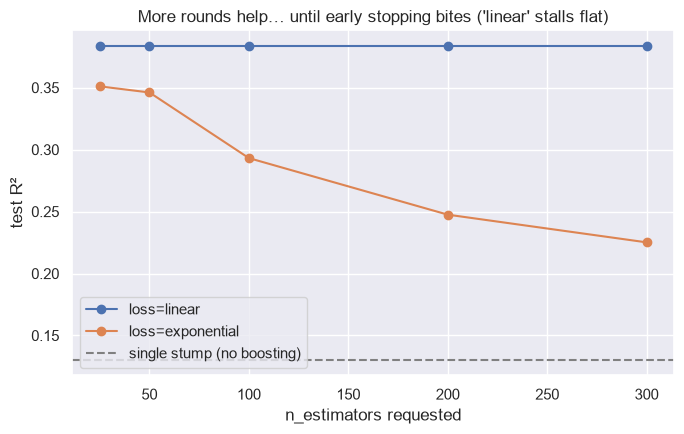

In [4]:
n_grid = [25, 50, 100, 200, 300]
curves = {}                                   # loss name -> list of test R²
for loss_name in ["linear", "exponential"]:   # two blame-rescaling schemes
    scores = []
    for n_est in n_grid:
        m = AdaBoostRegressor(DecisionTreeRegressor(max_depth=1),
                              n_estimators=n_est, loss=loss_name,
                              random_state=42).fit(X_train, y_train)
        scores.append(r2_score(y_test, m.predict(X_test)))
    curves[loss_name] = scores
    print(f"{loss_name:<12} rounds survived at n=300: {len(m.estimators_):>3}")

plt.figure(figsize=(7, 4.5))
for loss_name, scores in curves.items():
    plt.plot(n_grid, scores, marker="o", label=f"loss={loss_name}")
plt.axhline(stump.score(X_test, y_test), color="gray", ls="--",
            label="single stump (no boosting)")
plt.xlabel("n_estimators requested"); plt.ylabel("test R²")
plt.title("More rounds help… until early stopping bites ('linear' stalls flat)")
plt.legend(); plt.tight_layout(); plt.show()

### 4. Mini-grid: learning_rate × loss

`learning_rate` shrinks every estimator weight α_m; small steps usually want more
rounds. We scan 3 × 3 combinations at a fixed 200 requested rounds and read test R²
as a heatmap. ⚠️ This reads TEST performance for compactness - in real projects tune
on a validation split or cross-validation, and touch the test set once.

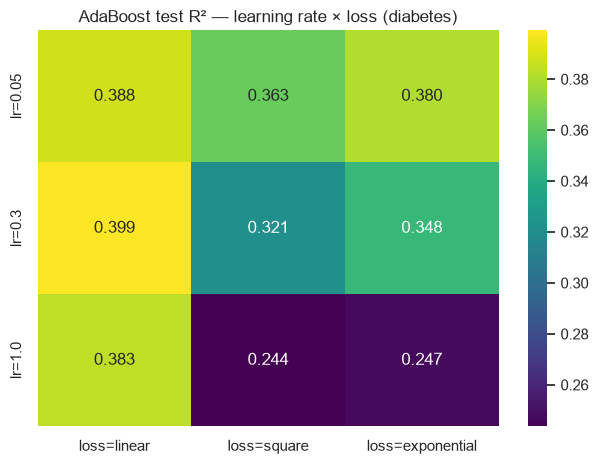

best combo: lr=0.3, loss=linear -> R²=0.399


In [5]:
lrs = [0.05, 0.3, 1.0]
losses = ["linear", "square", "exponential"]
grid = np.zeros((len(lrs), len(losses)))      # rows=lr, cols=loss

for i, lr in enumerate(lrs):
    for j, loss_name in enumerate(losses):
        m = AdaBoostRegressor(DecisionTreeRegressor(max_depth=1),
                              n_estimators=200, learning_rate=lr,
                              loss=loss_name, random_state=42).fit(X_train, y_train)
        grid[i, j] = r2_score(y_test, m.predict(X_test))

grid_df = pd.DataFrame(grid, index=[f"lr={v}" for v in lrs],
                       columns=[f"loss={v}" for v in losses])
sns.heatmap(grid_df, annot=True, fmt=".3f", cmap="viridis")
plt.title("AdaBoost test R² - learning rate × loss (diabetes)")
plt.tight_layout(); plt.show()

best_lr, best_loss = np.unravel_index(grid.argmax(), grid.shape)
print(f"best combo: lr={lrs[best_lr]}, loss={losses[best_loss]} -> R²={grid.max():.3f}")

### 5. What did the ensemble learn? Feature importances

Each stump splits on ONE feature, so `feature_importances_` literally counts how much
total squared-error reduction came through each feature across all surviving rounds.

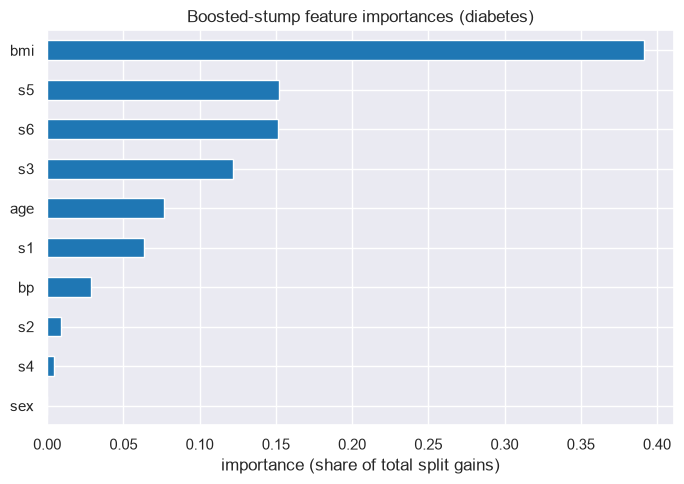

top-3: {'bmi': 0.392, 's5': 0.152, 's6': 0.151}


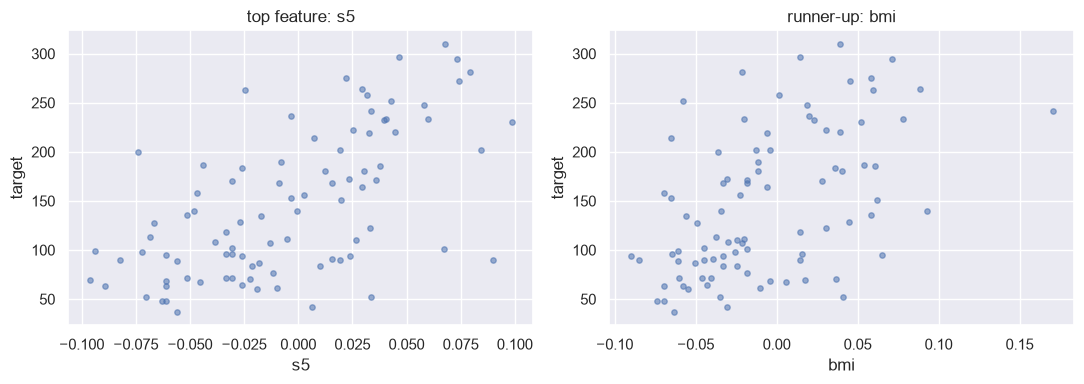

In [6]:
final_model = AdaBoostRegressor(DecisionTreeRegressor(max_depth=1),
                                n_estimators=300, loss="exponential",
                                random_state=42).fit(X_train, y_train)

imp = pd.Series(final_model.feature_importances_, index=X.columns).sort_values()
imp.plot.barh(figsize=(7, 5), color="tab:blue")
plt.title("Boosted-stump feature importances (diabetes)")
plt.xlabel("importance (share of total split gains)")
plt.tight_layout(); plt.show()
print("top-3:", imp.sort_values(ascending=False).head(3).round(3).to_dict())

# Sanity view: s5 and bmi against the target - do the winners make visual sense?
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["s5", "bmi"]):
    ax.scatter(X_test[col], y_test, s=15, alpha=0.55)
    ax.set_xlabel(col); ax.set_ylabel("target")
axes[0].set_title("top feature: s5")
axes[1].set_title("runner-up: bmi")
plt.tight_layout(); plt.show()

### 6. Final diagnostics on the chosen model


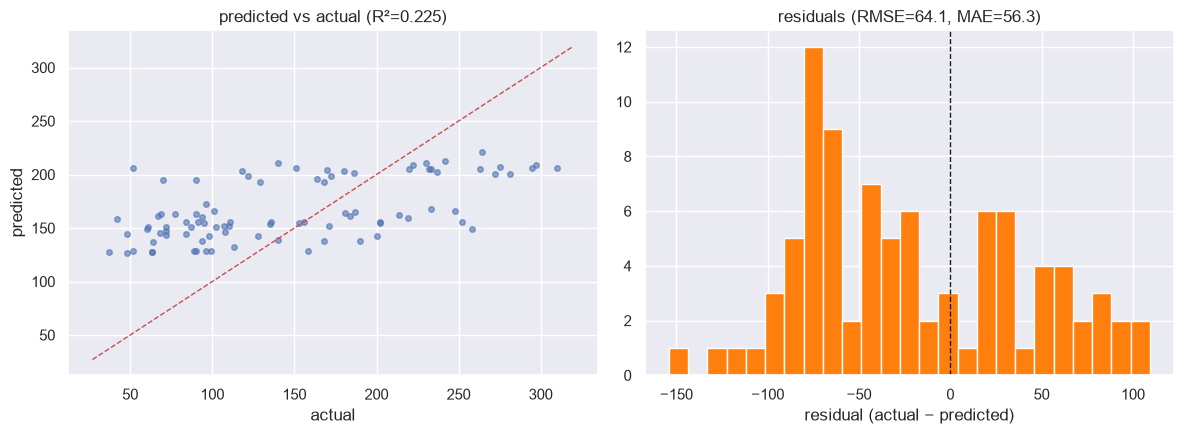

boosting gain over single stump: +0.095 R²


In [7]:
pred_test = final_model.predict(X_test)
rmse = mean_squared_error(y_test, pred_test) ** 0.5

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_test, pred_test, s=16, alpha=0.6)
lims = [y_test.min() - 10, y_test.max() + 10]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_xlabel("actual"); axes[0].set_ylabel("predicted")
axes[0].set_title(f"predicted vs actual (R²={r2_score(y_test, pred_test):.3f})")

residuals = y_test - pred_test
axes[1].hist(residuals, bins=25, color="tab:orange", edgecolor="white")
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("residual (actual - predicted)")
axes[1].set_title(f"residuals (RMSE={rmse:.1f}, MAE="
                  f"{mean_absolute_error(y_test, pred_test):.1f})")
plt.tight_layout(); plt.show()

print(f"boosting gain over single stump: "
      f"+{r2_score(y_test, pred_test) - stump.score(X_test, y_test):.3f} R²")

### Summary takeaways

- Workflow: split → dummy/stump/linear baselines → boost → curve/grid tuning → diagnostics.
- No `staged_predict` for regressors' AdaBoost - build rounds-curves with separate fits.
- ⚠️ Early stopping is real: `len(estimators_) < n_estimators` means boosting gave up;
  switching `loss="exponential"` typically keeps rounds alive longer.
- lr ↓ wants more rounds; the heatmap makes the interaction visible in one glance.
- Boosted stumps concentrate on `s5`/`bmi` - clinically sensible for progression.